# Гипотеза 2. Случайный лес (Random Forest)

## 2.1. Постановка гипотезы

**Гипотеза:** Ансамблевый метод на основе случайного леса способен уловить нелинейные зависимости между признаками и целевой переменной, недоступные линейным моделям, и обеспечить более высокое качество классификации по сравнению с базовой моделью (H1).

**Алгоритм:** Случайный лес (Random Forest Classifier).

**Обоснование выбора алгоритма:**

1. Разведочный анализ данных выявил нелинейные зависимости целевой переменной от признаков `balance`, `age` и `duration`, которые не могут быть адекватно описаны линейной моделью.
2. Алгоритм устойчив к выбросам, присутствующим в признаках `balance` и `duration`, поскольку деревья решений используют пороговые разбиения, а не абсолютные значения.
3. Встроенный механизм `feature_importances_` позволяет оценить значимость признаков и верифицировать выводы разведочного анализа.
4. Параметр `class_weight` обеспечивает компенсацию дисбаланса классов (88% / 12%) без дополнительной предобработки.
5. Нормализация признаков не является обязательным условием для деревьев решений.

## 2.2. Управляемые гиперпараметры

| Гиперпараметр | Описание | Диапазон поиска |
|---|---|---|
| `n_estimators` | Количество деревьев в ансамбле | `[100, 200, 500]` |
| `max_depth` | Максимальная глубина дерева | `[None, 5, 10, 20]` |
| `min_samples_split` | Минимальное число объектов для разбиения узла | `[2, 5, 10]` |
| `min_samples_leaf` | Минимальное число объектов в листовом узле | `[1, 2, 4]` |
| `class_weight` | Схема взвешивания классов | `[None, 'balanced', 'balanced_subsample']` |

## 2.3. Критерии качества

- **ROC-AUC** — основная метрика; устойчива к дисбалансу классов.
- **F1-score** для класса «yes» — баланс точности и полноты для целевого класса.
- **Classification Report** — детализированные метрики по каждому классу.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

%store -r X
%store -r y

## 2.4. Процедура подбора гиперпараметров

Ввиду большого пространства гиперпараметров применяется случайный поиск (`RandomizedSearchCV`, `n_iter=50`) в сочетании со стратифицированной 5-кратной перекрёстной проверкой. Целевая метрика оптимизации — `roc_auc`.

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X, y)

print(f"Оптимальные гиперпараметры: {search.best_params_}")
print(f"ROC-AUC (CV): {search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Оптимальные гиперпараметры: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': 'balanced_subsample'}
ROC-AUC (CV): 0.9100


## 2.5. Оценка качества оптимальной модели

Оценка производится методом out-of-fold (OOF) на стратифицированных разбиениях.

In [3]:
best_model = search.best_estimator_

y_pred_oof = np.zeros(len(y))
y_proba_oof = np.zeros(len(y))

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    best_model.fit(X_train, y_train)
    y_pred_oof[val_idx] = best_model.predict(X_val)
    y_proba_oof[val_idx] = best_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y, y_proba_oof)
f1 = f1_score(y, y_pred_oof)

print(f"ROC-AUC (OOF): {roc_auc:.4f}")
print(f"F1-score (класс 'yes'): {f1:.4f}")
print()
print(classification_report(y, y_pred_oof, target_names=['no', 'yes']))

ROC-AUC (OOF): 0.9096
F1-score (класс 'yes'): 0.4487

              precision    recall  f1-score   support

          no       0.92      0.97      0.94      4000
         yes       0.59      0.36      0.45       521

    accuracy                           0.90      4521
   macro avg       0.76      0.66      0.70      4521
weighted avg       0.88      0.90      0.89      4521



## 2.6. Оптимизация порога классификации

При стандартном пороге 0.5 модель склонна предсказывать преимущественно класс «no» ввиду дисбаланса классов 88% / 12%. Для улучшения качества предсказания класса «yes» выполняется поиск оптимального порога, максимизирующего F1-score для класса «yes» на OOF-прогнозах.

Оптимальный порог: 0.29
F1-score при пороге 0.50: 0.4487
F1-score при оптимальном пороге: 0.5751

              precision    recall  f1-score   support

          no       0.97      0.88      0.92      4000
         yes       0.45      0.78      0.58       521

    accuracy                           0.87      4521
   macro avg       0.71      0.83      0.75      4521
weighted avg       0.91      0.87      0.88      4521



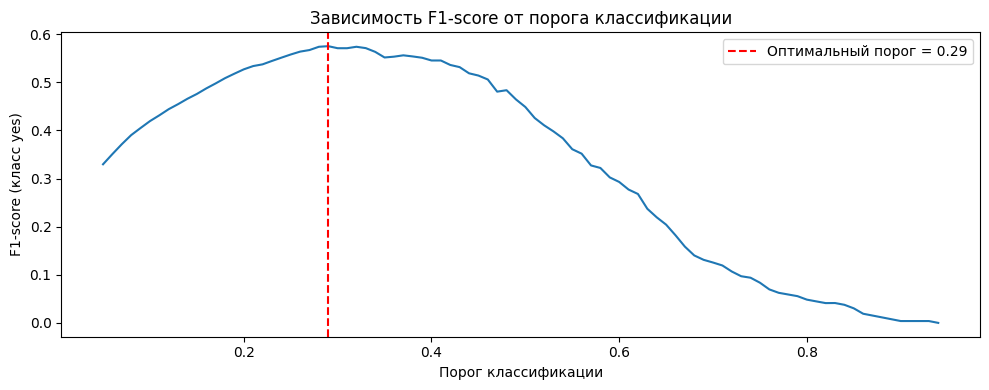

In [4]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y, (y_proba_oof >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
y_pred_opt = (y_proba_oof >= best_threshold).astype(int)

print(f"Оптимальный порог: {best_threshold:.2f}")
print(f"F1-score при пороге 0.50: {f1_score(y, y_pred_oof):.4f}")
print(f"F1-score при оптимальном пороге: {f1_score(y, y_pred_opt):.4f}")
print()
print(classification_report(y, y_pred_opt, target_names=['no', 'yes']))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores)
ax.axvline(best_threshold, color='red', linestyle='--', label=f'Оптимальный порог = {best_threshold:.2f}')
ax.set_xlabel('Порог классификации')
ax.set_ylabel('F1-score (класс yes)')
ax.set_title('Зависимость F1-score от порога классификации')
ax.legend()
plt.tight_layout()
plt.show()

## 2.7. ROC-кривая и матрица ошибок при оптимальном пороге

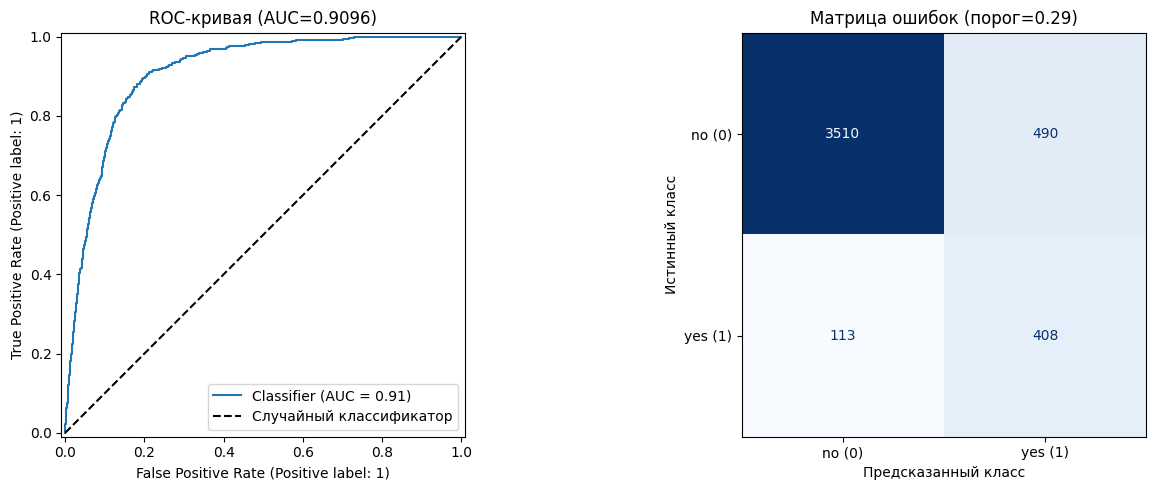

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y, y_proba_oof, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
axes[0].set_title(f'ROC-кривая (AUC={roc_auc:.4f})')
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y, y_pred_opt,
    display_labels=['no (0)', 'yes (1)'],
    cmap='Blues',
    colorbar=False,
    ax=axes[1]
)
axes[1].set_title(f'Матрица ошибок (порог={best_threshold:.2f})')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

## 2.8. Важность признаков

На рисунке представлены 15 признаков с наибольшим значением `feature_importances_` — встроенной меры важности, основанной на среднем снижении примеси (Mean Decrease in Impurity) по всем деревьям ансамбля.

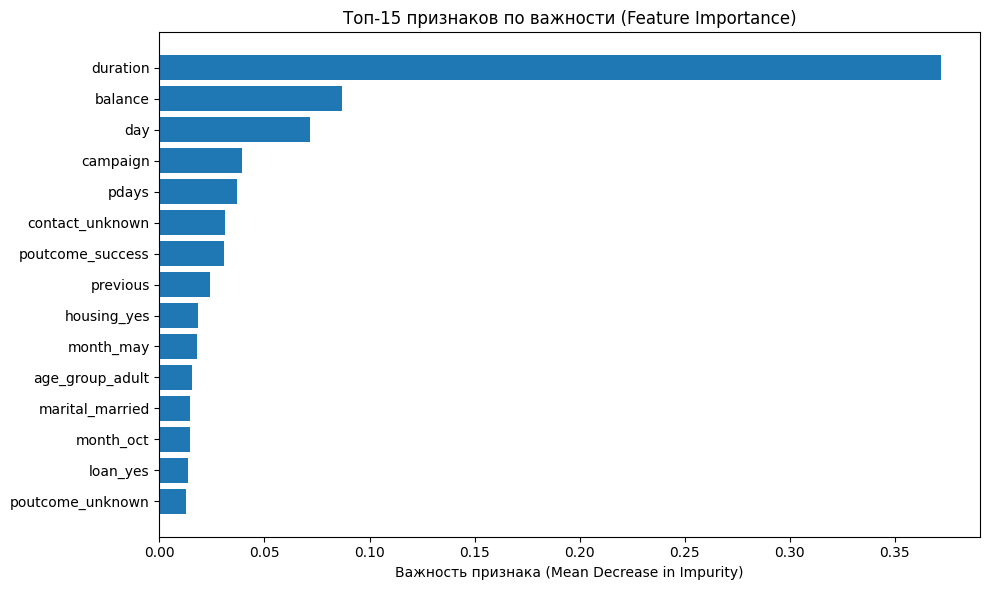

In [6]:
best_model.fit(X, y)
imp_df = pd.DataFrame({'feature': X.columns, 'importance': best_model.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df['feature'], imp_df['importance'])
ax.invert_yaxis()
ax.set_title('Топ-15 признаков по важности (Feature Importance)')
ax.set_xlabel('Важность признака (Mean Decrease in Impurity)')
plt.tight_layout()
plt.show()

## 2.9. Выводы

По результатам проверки гипотезы 2 установлено следующее:

1. Оптимальные значения гиперпараметров определены методом случайного поиска (`n_iter=50`) с применением стратифицированной 5-кратной перекрёстной проверки.
2. При стандартном пороге 0.5 модель демонстрирует низкий Recall для класса «yes». Оптимизация порога по F1-score позволяет существенно улучшить качество предсказания миноритарного класса за счёт незначительного снижения точности для класса «no».
3. Анализ важности признаков верифицирует выводы разведочного анализа данных: признаки `duration`, `balance` и `poutcome_success` вносят наибольший вклад в качество классификации.
4. Полученные значения ROC-AUC и F1-score сопоставляются с результатами базовой модели (H1) и служат ориентиром для оценки гипотез H3–H5.